# Multiband photometry: improved morphology and known-flux recovery

**All ten bands: Rubin u/g/r/i/z/y and Euclid VIS/Y/J/H.**

The old head learned an almost uniform size expansion. This version fits positive multiscale profiles, corrects the VIS ellipticity initialization for Gaussian weighting, and allows band-dependent component mixtures. Fluxes are still measured jointly from native pixels; the neural representation supplies a morphology prior, not a catalog-flux prediction.

Controls share the same PSFs, positions, pixels, and image fitter:
- Old single-Gaussian/global-correction model.
- Mixture with a population-average prior (no neural features).
- Mixture with a learned raw-VIS-image prior.
- Mixture with a foundation-assisted prior: raw VIS + frozen VIS stem + multiband bottleneck.

Shape targets come from bright sources fitted in the images. Noise degradation teaches the priors to work when VIS is weak. No external photometry labels enter training. Prior precision is calibrated from validation profile errors.

The simulation test below uses **known fluxes, independently rendered exponential core/disk galaxies, fresh encoder evaluation, color gradients, and both white and correlated noise**. It tests fixed known positions and PSFs; it is not a survey completeness or real-catalog accuracy claim.

“Image-only” describes the photometry prior. Real comparisons share the existing detection/astrometry outputs; simulations share known positions. The incremental test here does not measure the foundation’s detection or astrometry benefits.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "models/photometry").is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from models.photometry.self_supervised.core import BANDS
from models.photometry.self_supervised.benchmark_report import make_report, LABELS
BASE = ROOT / "models/photometry/self_supervised/runs"
RUN = BASE / "q1_mixture_calibrated"
torch.set_num_threads(4)
metadata = json.loads((RUN / "metadata.json").read_text())
protocol = json.loads((RUN / "injection_protocol.json").read_text())
print("Bands:", ", ".join(BANDS))
print("Independent bright training/validation sources:", metadata["independent_teacher_sources"])
print("Synthetic blends:", protocol["count"], "Sources:", 2 * protocol["count"], "Seed:", protocol["seed"])
print("Precision calibration:", metadata["precision_calibration"])

Bands: rubin_u, rubin_g, rubin_r, rubin_i, rubin_z, rubin_y, euclid_VIS, euclid_Y, euclid_J, euclid_H
Independent bright training/validation sources: {'train': 51, 'val': 17}
Synthetic blends: 128 Sources: 256 Seed: 20261201
Precision calibration: Validation curve-of-growth residual second moments; 20% diagonal shrinkage and 3% CDF floor; no injected truth used


## Photometry offset versus magnitude: before/after on the same axes

These are the **256 simulated sources**, in all ten bands, rather than the real MER comparison used for the supervised CNN. Gray: old Gaussian fit; orange: improved mixture with VIS-image prior; blue: improved mixture with foundation prior.

The vertical axis is $\Delta m=-2.5\log_{10}(F_{measured}/F_{true})$: positive means too faint. Curves show running medians (51-source windows); shading is the **16th–84th percentile distribution**, not a confidence interval on the median. All three magnitude curves use exactly the same positive-flux sources in each band. The companion fractional-flux plot retains negative measurements.

**Horizontal axes are instrumental magnitudes**, $-2.5\log_{10}F_{true}$ in each band's native units. Verified AB zero points were not retained in the tile/cache products. No arbitrary offset or 20-AB-mag cut is applied. Supplying verified per-band `zero_points` to `magnitude_report` enables AB axes and `min_magnitude=20`. Sliding windows avoid sparsely populated bright bins; the selection table reports omitted nonpositive measurements.

,band,total,common_positive,excluded_nonpositive
0,rubin_u,256,242,14
1,rubin_g,256,253,3
2,rubin_r,256,254,2
3,rubin_i,256,251,5
4,rubin_z,256,249,7
5,rubin_y,256,250,6
6,euclid_VIS,256,238,18
7,euclid_Y,256,245,11
8,euclid_J,256,245,11
9,euclid_H,256,247,9


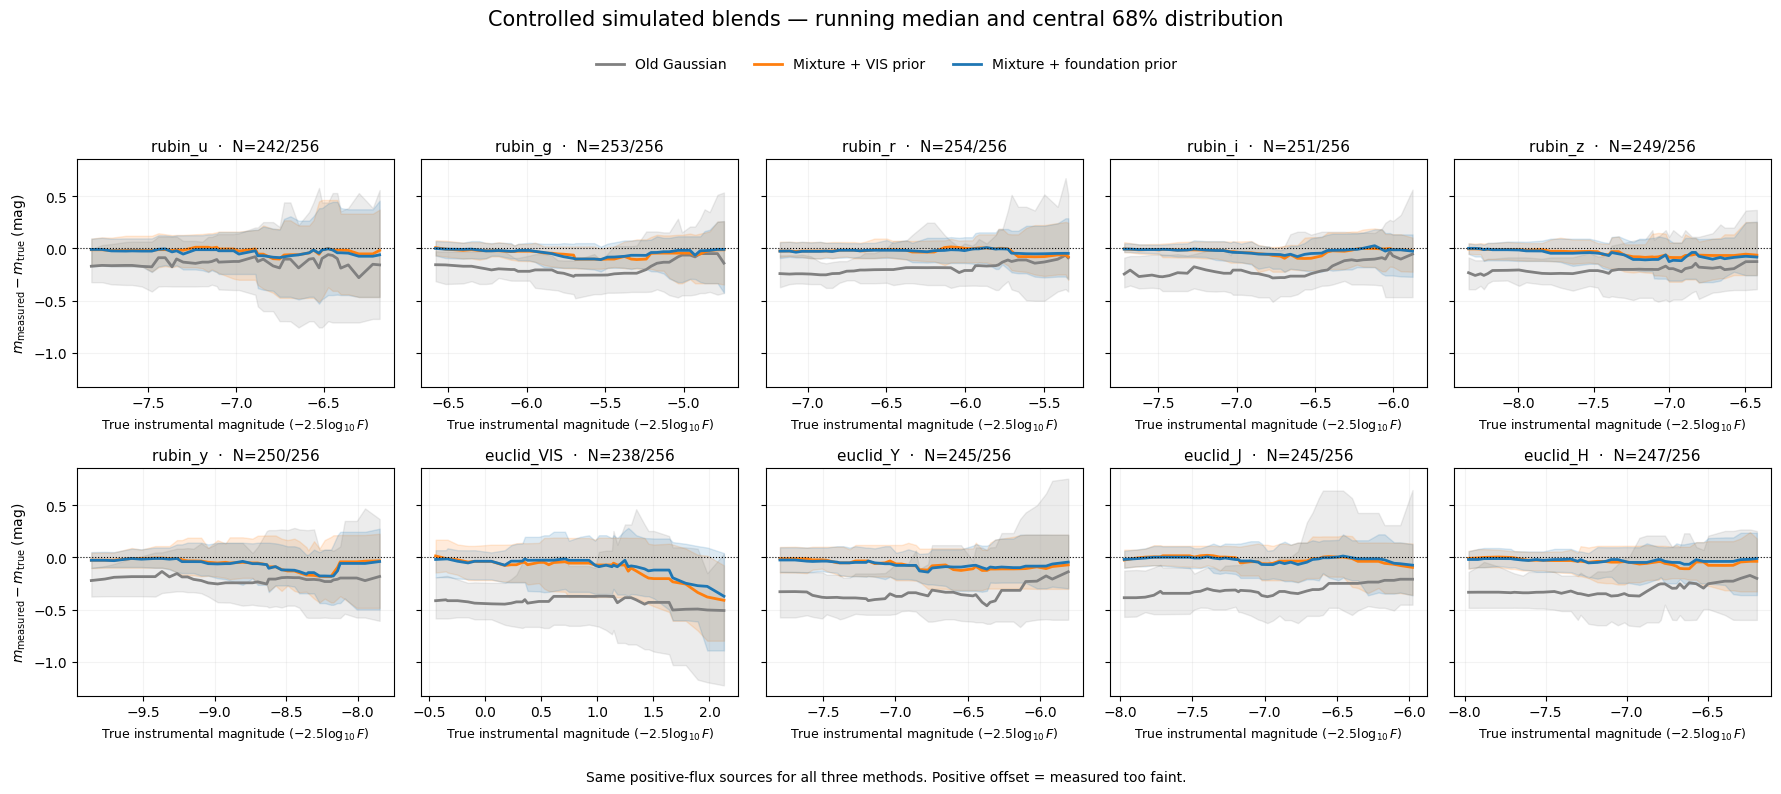

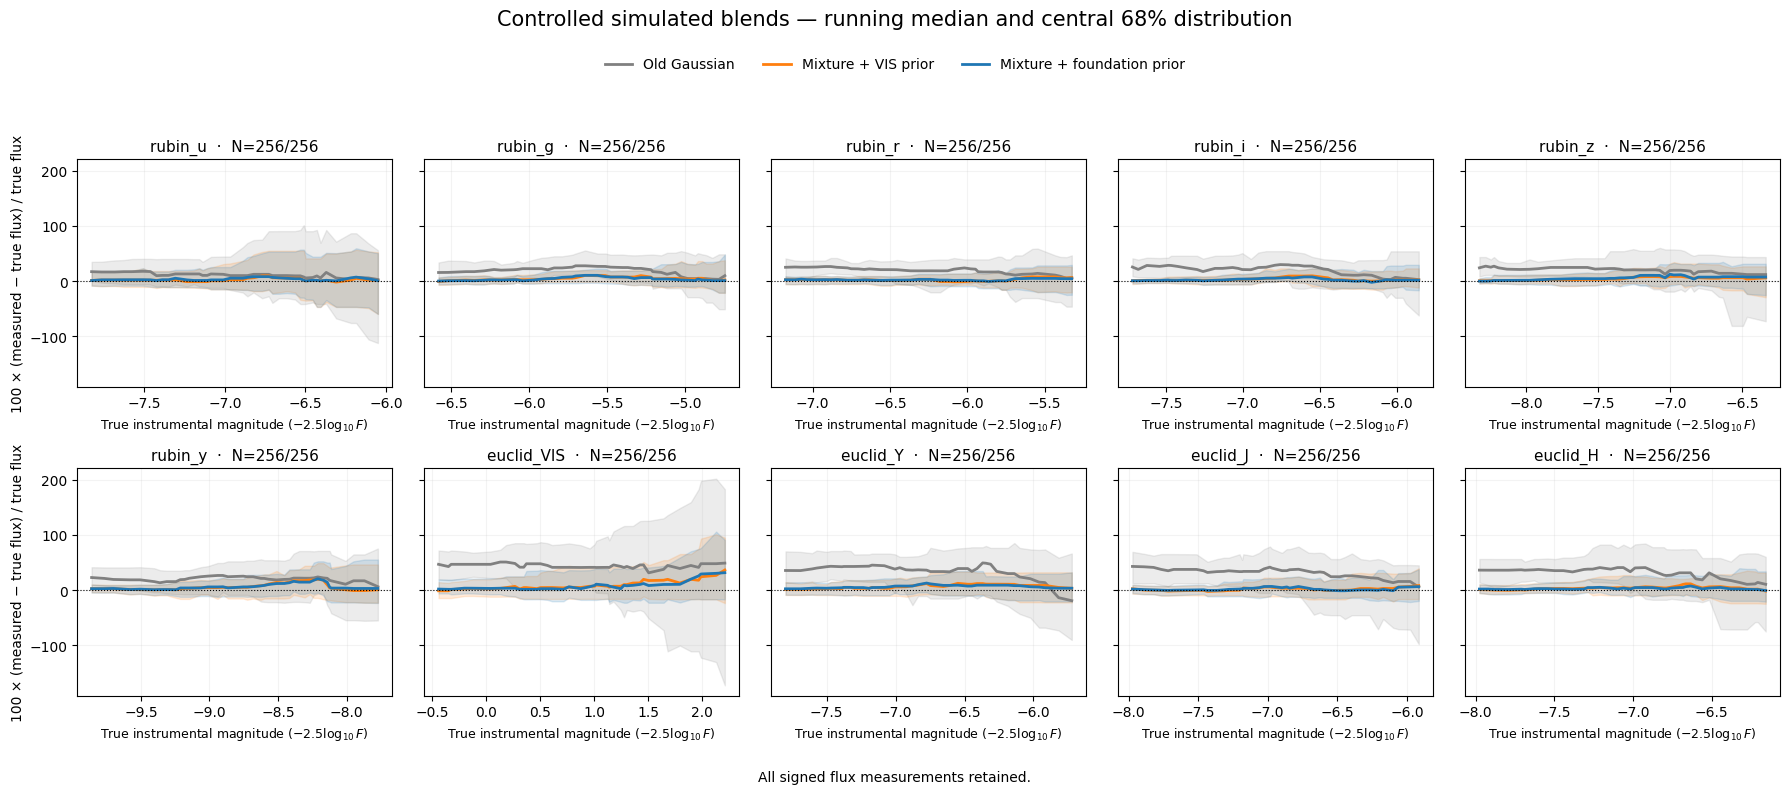

In [2]:
from models.photometry.self_supervised.benchmark_report import magnitude_report
magnitude_counts, magnitude_figures = magnitude_report(RUN)
display(magnitude_counts)
for figure in magnitude_figures:
    display(figure)
    plt.close(figure)

## Real Q1 scenes: reconstruction diagnostic

These 47 spatially held-out scenes were inspected during earlier development; treat this comparison as exploratory. Lower pixel χ² measures reconstruction, not correct flux sharing. The NISP χ² values also warn that supplied variance and correlated-noise treatment require further calibration.

In [3]:
old = json.loads((BASE / "q1_all_bands_constant/summary.json").read_text())["test"]["after"]
real = json.loads((RUN / "summary.json").read_text())
real_table = pd.DataFrame({"Old Gaussian": old, **{LABELS[k]: v for k, v in real.items()}}).reindex(BANDS)
real_table["Foundation change from old (%)"] = 100 * (real_table[LABELS["foundation"]] / real_table["Old Gaussian"] - 1)
display(real_table.round(4))
assert json.loads((RUN / "failures.json").read_text()) == [], "Inspect real-data failures"

,Old Gaussian,Mixture + population prior,Mixture + VIS prior,Mixture + foundation prior,Foundation change from old (%)
rubin_u,1.0116,1.0048,1.0049,1.0050,-0.6570
rubin_g,5.8383,3.7341,3.7356,3.7376,-35.9812
rubin_r,9.0055,3.0551,3.0566,3.0579,-66.0443
rubin_i,7.7531,3.0763,3.0772,3.0775,-60.3061
rubin_z,4.3631,2.2511,2.2517,2.2520,-48.3865
rubin_y,1.2790,1.1470,1.1471,1.1473,-10.3007
euclid_VIS,0.9660,0.5416,0.5417,0.5419,-43.8998
euclid_Y,0.0963,0.0637,0.0637,0.0638,-33.7502
euclid_J,0.1264,0.0693,0.0694,0.0695,-45.0419
euclid_H,0.1464,0.0802,0.0802,0.0803,-45.1458


## Fresh controlled test: flux accuracy

Each blend contains two sources separated by 0.4–1.4 arcsec. Half have VIS S/N reduced by three while other bands remain informative. Half use correlated noise. No simulation truth was used to choose these trained heads or their precision calibration. All methods receive the same noisy images and positions.

The statistic below is the median absolute fractional flux error, per band. It includes negative recovered fluxes; no positive-flux selection is applied. Values are in percent. Absolute magnitude zero points are not assumed.

Equal-band average of median absolute errors (%):


model,Old Gaussian,Mixture + population prior,Mixture + VIS prior,Mixture + foundation prior
band,,,,
rubin_u,28.40,15.05,15.33,15.03
rubin_g,23.94,8.34,8.36,7.65
rubin_r,24.45,7.45,7.31,7.19
rubin_i,25.88,6.08,6.91,5.90
rubin_z,27.53,9.60,8.32,9.61
rubin_y,27.84,12.99,13.55,12.35
euclid_VIS,54.33,19.51,18.09,19.01
euclid_Y,45.56,12.41,12.04,11.90
euclid_J,40.93,9.99,9.37,9.65


model
Old Gaussian                  33.61
Mixture + population prior    11.18
Mixture + VIS prior           10.93
Mixture + foundation prior    10.76
dtype: float64

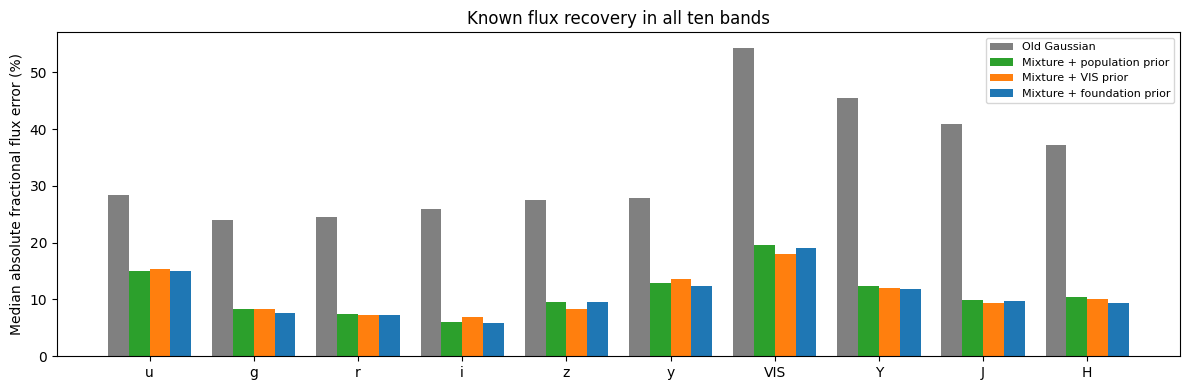

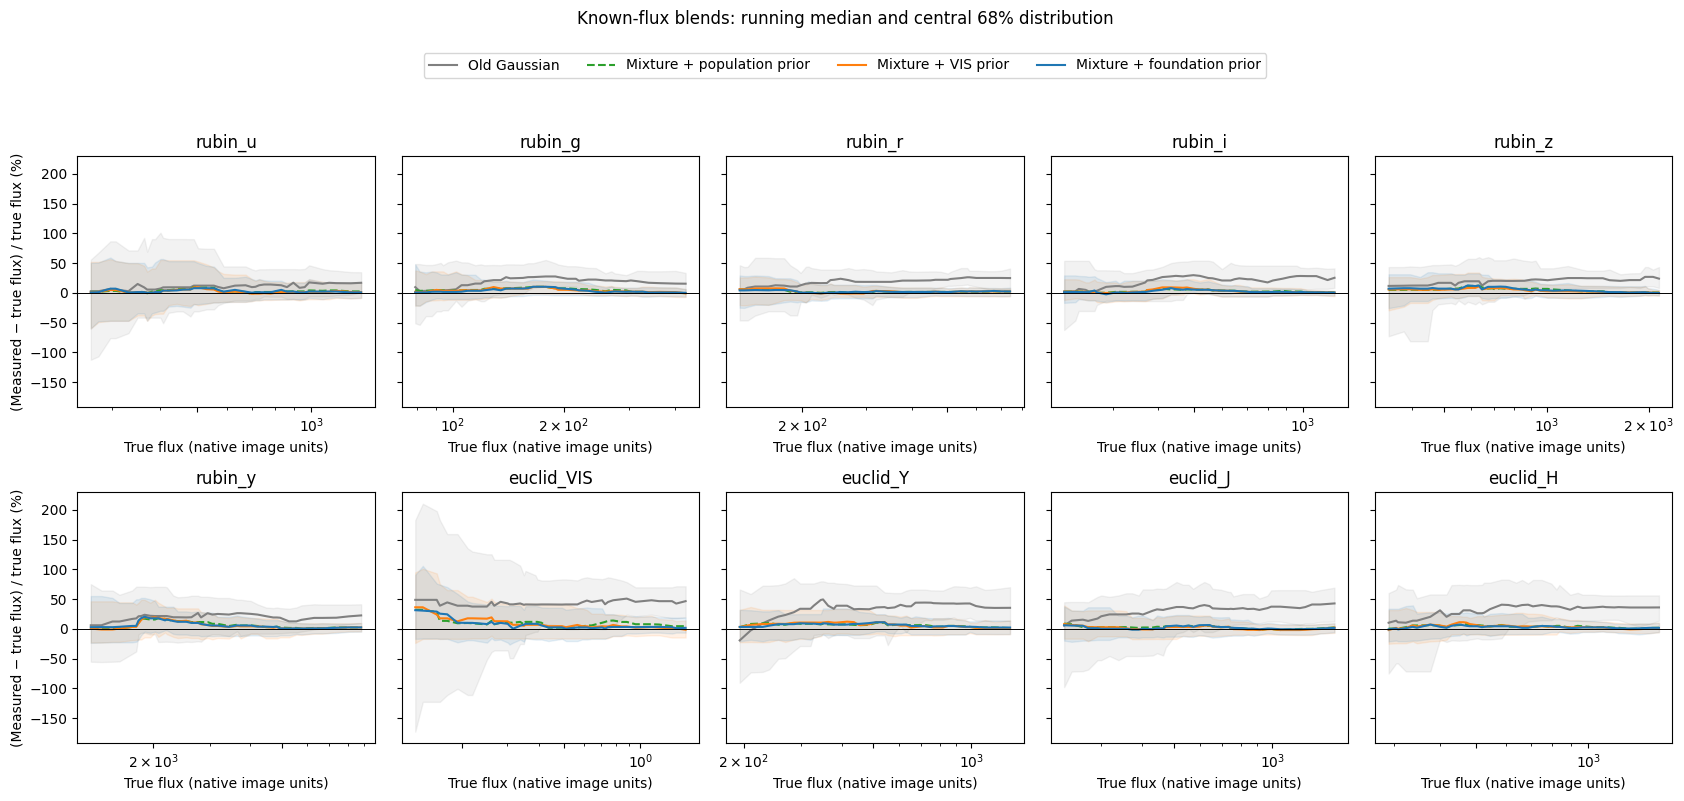

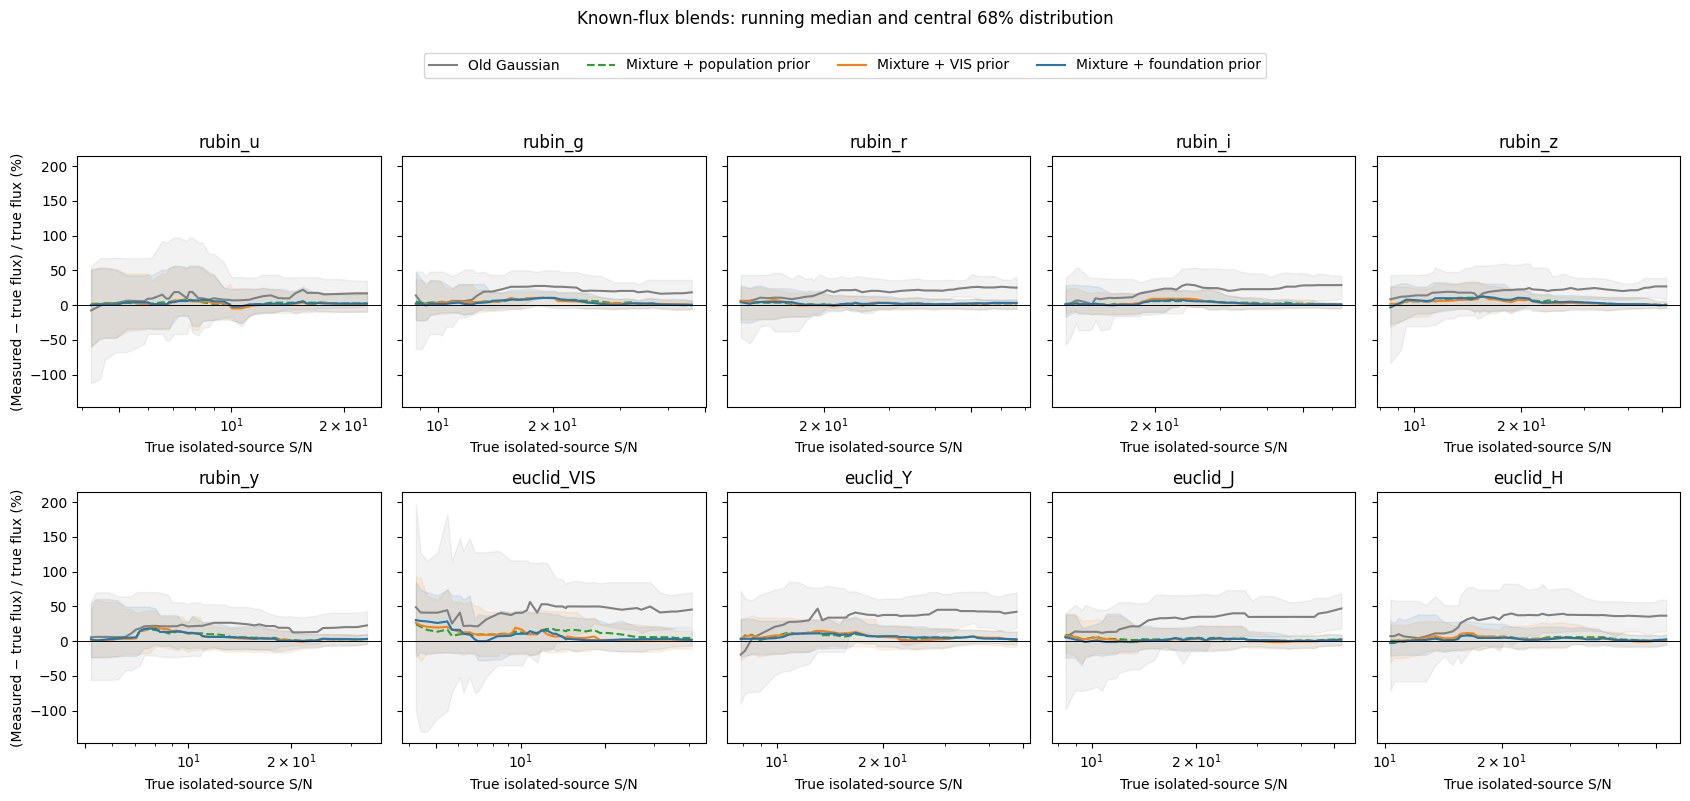

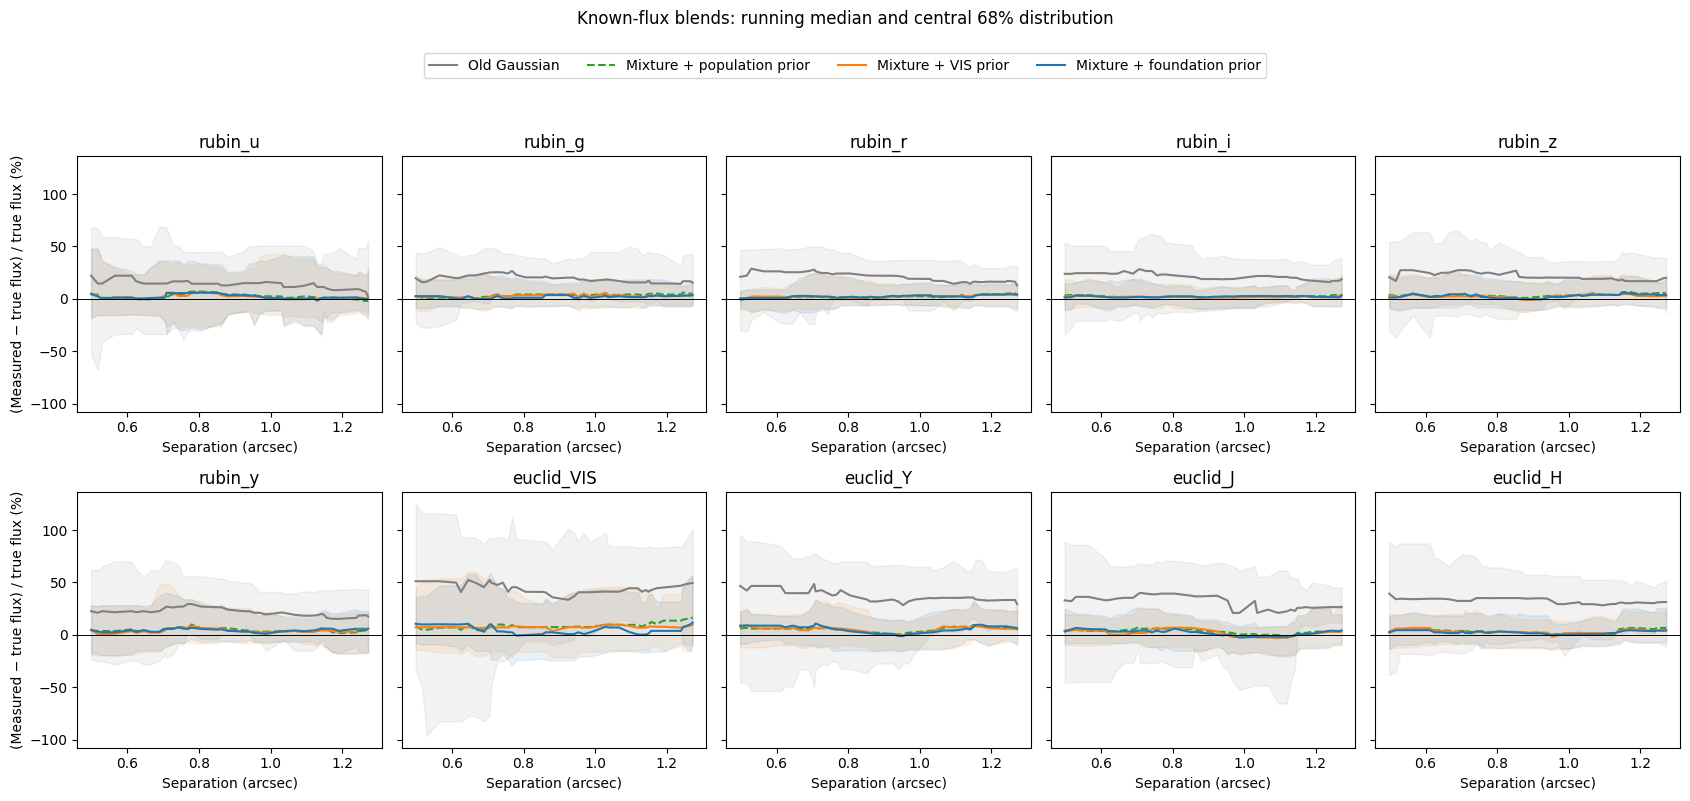

In [4]:
stats = pd.read_csv(RUN / "injection_summary.csv")
accuracy = 100 * stats.pivot(index="band", columns="model", values="median_absolute_error").reindex(BANDS)
accuracy = accuracy[["v1_global", "population", "image", "foundation"]]
display(accuracy.rename(columns=LABELS).round(2))
print("Equal-band average of median absolute errors (%):")
display(accuracy.mean().rename(index=LABELS).round(2))
assert json.loads((RUN / "injection_failures.json").read_text()) == [], "Inspect simulation failures"
comparison, figures = make_report(RUN)
for figure in figures:
    display(figure)
    plt.close(figure)

Lines show running medians; shading shows the central **16th–84th percentile distribution of sources**, not uncertainty on the median. The population-prior curve is dashed without shading. The panel sets use true native-unit flux, true isolated-source S/N, and source separation. Absolute magnitude zero points are not assumed.

## Is the foundation itself helping?

The following paired bootstrap resamples whole blends, retaining both sources and all bands together. Negative differences favor the foundation. Confidence intervals include sampling uncertainty of the simulated blends, conditional on the fitted models. They do not include PSF-model or training-set uncertainty. An interval crossing zero is inconclusive.

In [5]:
paired = comparison[(comparison.reference == "image") & (comparison.band == "equal_band_average")].copy()
for column in ["foundation_median_abs_error", "reference_median_abs_error", "difference", "ci_low", "ci_high"]:
    paired[column] *= 100
paired = paired.set_index("subset")[["n_blends", "foundation_median_abs_error", "reference_median_abs_error", "difference", "ci_low", "ci_high"]]
display(paired.round(3))
per_band = comparison[(comparison.reference == "image") & (comparison.subset == "all") & (comparison.band != "equal_band_average")].set_index("band").reindex(BANDS)
display((100 * per_band[["difference", "ci_low", "ci_high"]]).round(3))

,n_blends,foundation_median_abs_error,reference_median_abs_error,difference,ci_low,ci_high
subset,,,,,,
all,128,10.759,10.928,-0.169,-0.650,0.450
weak_VIS,64,12.447,12.172,0.274,-0.800,1.021
normal_VIS,64,9.772,9.930,-0.157,-0.913,0.424
white_noise,64,7.623,7.607,0.016,-0.683,0.728
correlated_noise,64,15.392,15.437,-0.045,-0.936,0.638


,difference,ci_low,ci_high
band,,,
rubin_u,-0.297,-1.132,1.518
rubin_g,-0.709,-1.918,0.414
rubin_r,-0.117,-0.927,0.818
rubin_i,-1.016,-2.002,0.406
rubin_z,1.287,-0.511,1.944
rubin_y,-1.207,-2.588,0.993
euclid_VIS,0.921,-1.709,3.874
euclid_Y,-0.140,-1.235,1.848
euclid_J,0.282,-1.282,1.681


## An injected crowded scene in every band

Residual panels use the same ±5 supplied-pixel-σ color scale. They help inspect model failures but are secondary to known-flux errors. The stored example is a fixed early simulation, not selected for favorable model performance.

{'seed': 20261201, 'separation_arcsec': 1.0666439227823372, 'correlated_noise': True, 'weak_vis': True, 'sizes_arcsec': [0.16382542867043964, 0.15713003120463948], 'axis_ratios': [0.8680796895506397, 0.7042211692770216]}


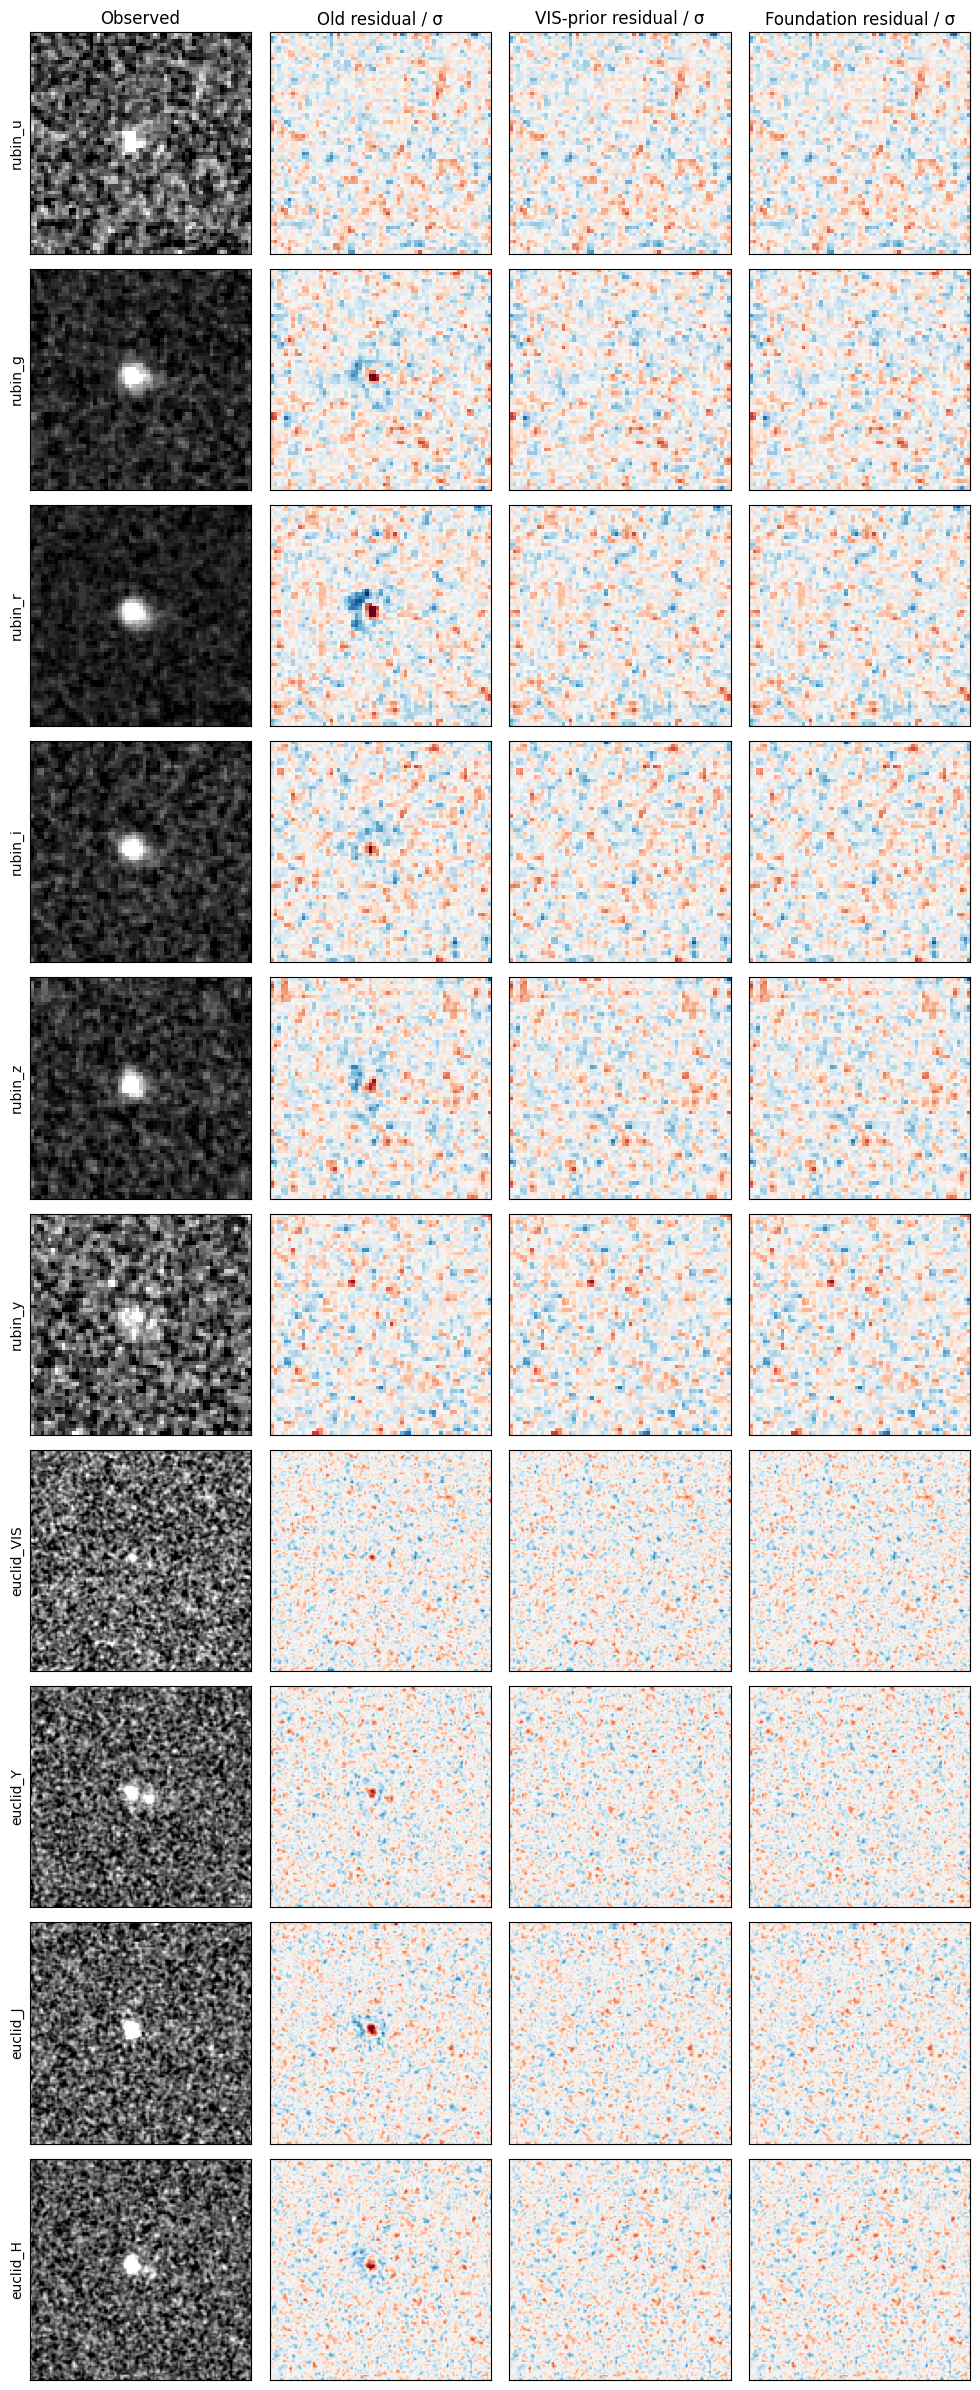

In [6]:
example = torch.load(RUN / "injection_examples.pt", map_location="cpu", weights_only=False)[0]
fig, axes = plt.subplots(10, 4, figsize=(10, 24))
for row, band in enumerate(BANDS):
    d = example["scene"]["bands"][band]
    im, rms = d["image"].numpy(), np.sqrt(d["variance"].numpy())
    lo, hi = np.percentile(im, [5, 99.5])
    axes[row, 0].imshow(im, origin="lower", cmap="gray", vmin=lo, vmax=hi)
    axes[row, 0].set_ylabel(band)
    for col, mode in enumerate(["v1_global", "image", "foundation"], 1):
        residual = (im - example["fits"][mode][band]["model"]) / rms
        axes[row, col].imshow(residual, origin="lower", cmap="RdBu_r", vmin=-5, vmax=5)
    for ax in axes[row]: ax.set_xticks([]); ax.set_yticks([])
for ax, title in zip(axes[0], ["Observed", "Old residual / σ", "VIS-prior residual / σ", "Foundation residual / σ"]): ax.set_title(title)
fig.tight_layout()
fig.savefig(RUN / "injected_scene_all_bands.png", dpi=120)
display(fig)
plt.close(fig)
print(example["config"])

## Reusable inference

`MixturePhotometry` loads a trained prior and evaluates all ten bands. It recomputes the foundation features from the actual input scene, including any injected or altered pixels. `mode="image"` and `mode="population"` use the same fitter without running the foundation.

Scene dictionaries contain native image, variance, valid-pixel mask, source pixel positions, sky-to-pixel Jacobian, and PSF width for each band. Flux errors remain conditional on the fitted profile/PSF; the profile-selection and PSF uncertainties are not included in the reported errors.

In [7]:
from models.photometry.self_supervised.predict import MixturePhotometry
prepared = torch.load(BASE / "q1_mixture/prepared.pt", map_location="cpu", weights_only=False)
photometer = MixturePhotometry(RUN / "priors.pt", mode="foundation")
scene = prepared["test"][0]["scene"]
measurement = photometer(scene)
central = scene["central"]
display(pd.DataFrame({b: {"native_flux": r["flux"][central], "conditional_error": r["error"][central], "model_footprint": r["footprint"][central]} for b, r in measurement.items()}).T.reindex(BANDS))
expected = torch.load(RUN / "fits.pt", map_location="cpu", weights_only=False)[0]["foundation"]
for band in BANDS:
    np.testing.assert_allclose(measurement[band]["flux"], expected[band]["flux"], rtol=1e-6, atol=1e-6, equal_nan=True)
print("Fresh inference reproduces saved all-band measurements.")

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v11 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2, compression=asinh50) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v11_q1_soft/checkpoint_best.pt
Fresh inference reproduces saved all-band measurements.


,native_flux,conditional_error,model_footprint
rubin_u,131.230951,66.231296,0.999938
rubin_g,115.473295,10.063490,0.999916
rubin_r,210.109383,14.025518,0.999888
rubin_i,503.980785,24.242320,0.999896
rubin_z,1043.625022,47.725822,0.999898
rubin_y,1042.815166,263.121628,0.999966
euclid_VIS,0.734771,0.035180,0.999977
euclid_Y,266.060533,30.482587,0.999976
euclid_J,518.231102,34.393983,0.999957
euclid_H,634.389116,35.584247,0.999967


## Result and scope

On this fresh set of 128 blends (256 sources), the equal-band average of median absolute flux error decreases from **33.61% to 10.76%** versus the old Gaussian model—a **68.0% reduction**. Every band improves. The image-only mixture achieves **10.93%**.

The foundation's extra improvement over that strong image-only control is **0.17 percentage points**. The paired bootstrap interval for foundation minus image-only is **−0.65 to +0.45 points**, so a foundation-specific gain is **not established**. The main demonstrated advance is better physical modeling and joint deblending, with an object-dependent, noise-trained foundation prior available and properly controlled.

The benchmark uses analytic core/disk galaxies with known positions and the assumed approximate PSF. It does not establish performance on real complex morphologies, missing detections, uncertain astrometry, spatial PSF errors, or calibrated survey fluxes. Native-unit fluxes have not been converted to microJy/AB magnitudes. Real-data reference matching and realistic additive injections remain separate checks.

The pretrained encoder/astrometry may have seen the real held-out sky; the downstream prior is trained only on its training split. The fresh simulation seeds are not used to fit the priors. See `README.md` for exact reproduction commands and preserved earlier experiments.